
--- جاري تحميل البيانات ---

الأقسام المتاحة في قاعدة البيانات: ['by_polishing', 'from_title', 'from_title_and_content']

--- استكشاف البيانات (القيم المفقودة والمكررة) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8388 entries, 0 to 8387
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   original_abstract          8388 non-null   object
 1   allam_generated_abstract   8388 non-null   object
 2   jais_generated_abstract    8388 non-null   object
 3   llama_generated_abstract   8388 non-null   object
 4   openai_generated_abstract  8388 non-null   object
dtypes: object(5)
memory usage: 327.8+ KB

القيم المفقودة:
 original_abstract            0
allam_generated_abstract     0
jais_generated_abstract      0
llama_generated_abstract     0
openai_generated_abstract    0
dtype: int64

القيم المكررة: 0

--- تجهيز البيانات للتصنيف (بشري مقابل ذكاء اصطناعي) ---

توزيع البيانات:
 label
AI-Gene

/tmp/ipykernel_2419/1084834021.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=final_df, x='label', palette='pastel')


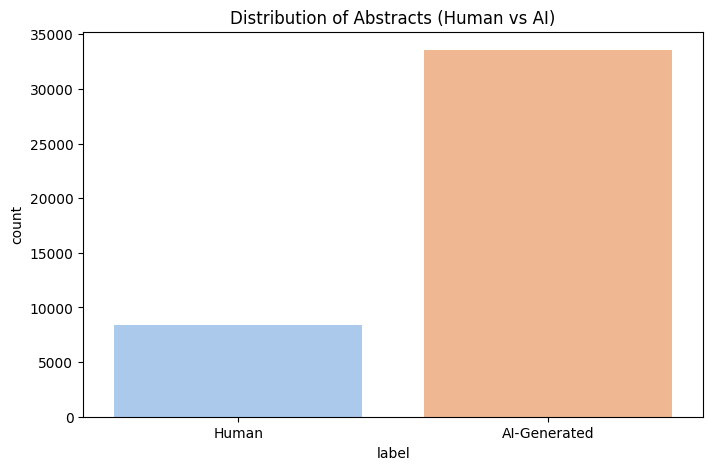

In [3]:
# 1. تثبيت المكتبات المطلوبة (إذا لم تكن مثبتة)
!pip install datasets pandas matplotlib seaborn

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- جاري تحميل البيانات ---")
# 2. تحميل مجموعة البيانات من Hugging Face
dataset = load_dataset("KFUPM-JRCAI/arabic-generated-abstracts")

# طباعة الأقسام الموجودة لمعرفة أسمائها الفعلية
print("\nالأقسام المتاحة في قاعدة البيانات:", list(dataset.keys()))

# 3. تحويل جميع الأقسام المتاحة إلى DataFrame ودمجها معاً
df_list = []
for split_name in dataset.keys():
    df_list.append(pd.DataFrame(dataset[split_name]))

df = pd.concat(df_list, ignore_index=True)

print("\n--- استكشاف البيانات (القيم المفقودة والمكررة) ---")
# 4. فحص هيكل البيانات
df.info()
print("\nالقيم المفقودة:\n", df.isnull().sum())
print("\nالقيم المكررة:", df.duplicated().sum())

print("\n--- تجهيز البيانات للتصنيف (بشري مقابل ذكاء اصطناعي) ---")
# 5. دمج الأعمدة لإعداد متغير الهدف (Label)
human_df = df[['original_abstract']].copy()
human_df.columns = ['text']
human_df['label'] = 'Human'

ai_models = ['allam_generated_abstract', 'jais_generated_abstract', 'llama_generated_abstract', 'openai_generated_abstract']
ai_dfs = []
for model in ai_models:
    temp_df = df[[model]].copy()
    temp_df.columns = ['text']
    temp_df['label'] = 'AI-Generated'
    ai_dfs.append(temp_df)

final_df = pd.concat([human_df] + ai_dfs, ignore_index=True)
print("\nتوزيع البيانات:\n", final_df['label'].value_counts())

# 6. رسم بياني للتوزيع
plt.figure(figsize=(8, 5))
sns.countplot(data=final_df, x='label', palette='pastel')
plt.title('Distribution of Abstracts (Human vs AI)')
plt.show()